# Static Variables Editor

This notebook loads a static-variable pickle, visualizes variables on Cartopy maps, and lets you modify a variable and compare before/after maps.

## Requirements

Install once if needed:

```bash
pip install numpy matplotlib cartopy
```

In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Update this path to your static-variable pickle.
STATIC_PICKLE_PATH = Path("/mnt/data2/cams/aurora-0.4-air-pollution-static.pickle")

if not STATIC_PICKLE_PATH.exists():
    raise FileNotFoundError(f"Static pickle not found: {STATIC_PICKLE_PATH}")

with open(STATIC_PICKLE_PATH, "rb") as f:
    static_vars = pickle.load(f)

if not isinstance(static_vars, dict):
    raise TypeError(f"Expected pickle to contain a dict, got: {type(static_vars)}")

print(f"Loaded static variables from: {STATIC_PICKLE_PATH}")
print(f"Number of variables: {len(static_vars)}")
print(f"Variable names: {list(static_vars.keys())}")

TARGET_BASE_STATIC_VARS = ["static_ammonia", "static_co", "static_nox", "static_so2"]
MODIFIABLE_BASE_VARS = [name for name in TARGET_BASE_STATIC_VARS if name in static_vars]
if not MODIFIABLE_BASE_VARS:
    raise KeyError(
        "None of the expected modifiable variables are present in the pickle: "
        f"{TARGET_BASE_STATIC_VARS}"
    )

BASE_TO_LOG_VAR = {
    base_name: f"{base_name}_log"
    for base_name in MODIFIABLE_BASE_VARS
    if f"{base_name}_log" in static_vars
}

print(f"Modifiable base variables: {MODIFIABLE_BASE_VARS}")
print(f"Auto-updated log variables: {BASE_TO_LOG_VAR}")


Loaded static variables from: /mnt/data2/cams/aurora-0.4-air-pollution-static.pickle
Number of variables: 11
Variable names: ['lsm', 'z', 'slt', 'static_ammonia', 'static_ammonia_log', 'static_co', 'static_co_log', 'static_nox', 'static_nox_log', 'static_so2', 'static_so2_log']
Modifiable base variables: ['static_ammonia', 'static_co', 'static_nox', 'static_so2']
Auto-updated log variables: {'static_ammonia': 'static_ammonia_log', 'static_co': 'static_co_log', 'static_nox': 'static_nox_log', 'static_so2': 'static_so2_log'}


/tmp/ipykernel_784827/3132194767.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  static_vars = pickle.load(f)


In [3]:
def to_numpy_array(value):
    if isinstance(value, np.ndarray):
        return value
    if hasattr(value, "detach") and hasattr(value, "cpu"):
        return value.detach().cpu().numpy()
    if hasattr(value, "values"):
        return np.asarray(value.values)
    return np.asarray(value)


def to_2d_view(array):
    arr = np.asarray(array)
    arr = np.squeeze(arr)
    if arr.ndim < 2:
        raise ValueError(f"Need at least 2 dimensions to map, got shape {arr.shape}")
    leading_indices = ()
    while arr.ndim > 2:
        arr = arr[0]
        leading_indices += (0,)
    return arr, leading_indices


def infer_lat_lon(static_dict, sample_2d):
    lat = None
    lon = None

    for key in ["lat", "latitude", "lats"]:
        if key in static_dict:
            candidate = np.asarray(to_numpy_array(static_dict[key])).squeeze()
            if candidate.ndim == 1 and candidate.size == sample_2d.shape[0]:
                lat = candidate
                break

    for key in ["lon", "longitude", "lons"]:
        if key in static_dict:
            candidate = np.asarray(to_numpy_array(static_dict[key])).squeeze()
            if candidate.ndim == 1 and candidate.size == sample_2d.shape[1]:
                lon = candidate
                break

    if lat is None:
        lat = np.linspace(90.0, -90.0, sample_2d.shape[0])
    if lon is None:
        lon = np.linspace(0.0, 360.0, sample_2d.shape[1], endpoint=False)

    return lat, lon


def _prepare_longitudes_for_plot(data_2d, lon_1d):

    data_arr = np.asarray(data_2d)

    lon_arr = np.asarray(lon_1d, dtype=np.float64).squeeze()



    if lon_arr.ndim != 1:

        raise ValueError(f"Expected 1D longitudes, got shape {lon_arr.shape}")

    if data_arr.shape[-1] != lon_arr.size:

        raise ValueError(

            "Longitude size must match data width. "

            f"Got lon size {lon_arr.size}, data width {data_arr.shape[-1]}"

        )



    # Always wrap to [-180, 180) so both [0, 360) and [-180, 180] style inputs plot correctly.

    lon_wrapped = ((lon_arr + 180.0) % 360.0) - 180.0



    # Keep longitudes monotonic and reorder data columns accordingly.

    order = np.argsort(lon_wrapped)

    lon_sorted = lon_wrapped[order]

    data_sorted = np.take(data_arr, order, axis=-1)



    # Remove duplicate longitudes that can appear after wrapping.

    rounded = np.round(lon_sorted, 10)

    _, unique_idx = np.unique(rounded, return_index=True)

    unique_idx = np.sort(unique_idx)

    lon_sorted = lon_sorted[unique_idx]

    data_sorted = np.take(data_sorted, unique_idx, axis=-1)



    # Add a cyclic point to avoid a visible seam on global maps.

    if lon_sorted.size > 1:

        step = np.median(np.diff(lon_sorted))

        if not np.isfinite(step) or step == 0:

            step = 360.0 / lon_sorted.size

        lon_plot = np.concatenate([lon_sorted, [lon_sorted[-1] + step]])

        data_plot = np.concatenate([data_sorted, data_sorted[..., :1]], axis=-1)

    else:

        lon_plot = lon_sorted

        data_plot = data_sorted



    return data_plot, lon_plot




def _add_map(

    ax,

    data_2d,

    lat_1d,

    lon_1d,

    title,

    cmap="viridis",

    vmin=None,

    vmax=None,

    zero_white=True,

):

    data_arr = np.asarray(data_2d)

    data_arr, lon_plot = _prepare_longitudes_for_plot(data_arr, lon_1d)

    lon2d, lat2d = np.meshgrid(lon_plot, lat_1d)



    plot_arr = data_arr

    if zero_white:

        finite = np.isfinite(data_arr)

        data_nonneg = bool(finite.any()) and np.nanmin(data_arr[finite]) >= 0

        if data_nonneg:

            color_values = plt.get_cmap(cmap)(np.linspace(0.0, 1.0, 256))

            color_values[0] = np.array([1.0, 1.0, 1.0, 1.0])

            cmap_obj = ListedColormap(color_values)

            if vmin is None:

                vmin = 0.0

            else:

                vmin = min(float(vmin), 0.0)

            if vmax is None:

                vmax = float(np.nanmax(data_arr[finite])) if finite.any() else 1.0

            else:

                vmax = float(vmax)

            if not np.isfinite(vmax) or vmax <= vmin:

                vmax = vmin + 1.0

        else:

            cmap_obj = plt.get_cmap(cmap)

    else:

        cmap_obj = plt.get_cmap(cmap)



    ax.set_global()

    ax.coastlines(linewidth=0.6)

    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    ax.gridlines(draw_labels=False, linewidth=0.2, alpha=0.5)

    mesh = ax.pcolormesh(

        lon2d,

        lat2d,

        plot_arr,

        transform=ccrs.PlateCarree(),

        shading="auto",

        cmap=cmap_obj,

        vmin=vmin,

        vmax=vmax,

    )

    ax.set_title(title)

    return mesh




def plot_single_map(
    data_2d,
    lat_1d,
    lon_1d,
    title,
    cmap="viridis",
    vmin=None,
    vmax=None,
    zero_white=True,
):
    fig, ax = plt.subplots(
        1,
        1,
        figsize=(11, 4.8),
        subplot_kw={"projection": ccrs.Robinson()},
    )
    mesh = _add_map(
        ax,
        data_2d,
        lat_1d,
        lon_1d,
        title,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        zero_white=zero_white,
    )
    plt.colorbar(mesh, ax=ax, shrink=0.8, pad=0.03, label="Value")
    plt.tight_layout()
    plt.show()


def convert_back_to_template(template_value, modified_np):
    if hasattr(template_value, "detach") and hasattr(template_value, "dtype"):
        try:
            import torch

            return torch.as_tensor(modified_np, dtype=template_value.dtype)
        except Exception:
            return modified_np
    if isinstance(template_value, np.ndarray):
        return modified_np.astype(template_value.dtype, copy=False)
    return modified_np


def compute_static_log(base_np, eps=1e-12):
    base_arr = np.asarray(base_np)
    return np.log(np.clip(base_arr, eps, None))


BASE_VAR_ALIASES = {
    "ammonia": "static_ammonia",
    "co": "static_co",
    "nox": "static_nox",
    "so2": "static_so2",
}


def resolve_base_var_name(var_name):
    if var_name in MODIFIABLE_BASE_VARS:
        return var_name
    return BASE_VAR_ALIASES.get(var_name, var_name)


## Add New Static Variable

Optional helper: create a new static base variable and a matching `_log` variable in memory.

Compatibility note: adding keys to the pickle does **not** make default `AuroraAirPollution()` use them.
You must also extend `model.static_vars`, provide normalisation stats, and load checkpoint with `strict=False`.


In [4]:
# Add a new static base variable and its paired _log variable.
ADD_NEW_VARIABLE = False
NEW_BASE_VAR_NAME = "static_custom"
NEW_LOG_VAR_NAME = f"{NEW_BASE_VAR_NAME}_log"

INIT_MODE = "copy"  # "copy", "zeros", "constant"
SOURCE_BASE_VAR = MODIFIABLE_BASE_VARS[0]
CONSTANT_VALUE = 0.0
NEW_LOG_EPS = 1e-12

SAVE_PICKLE_WITH_NEW_VAR = False
NEW_VAR_OUTPUT_PICKLE = STATIC_PICKLE_PATH.with_name(
    STATIC_PICKLE_PATH.stem + f"-with-{NEW_BASE_VAR_NAME}.pickle"
)

DEFAULT_AP_STATIC_VARS = {
    "lsm",
    "slt",
    "z",
    "static_ammonia",
    "static_ammonia_log",
    "static_co",
    "static_co_log",
    "static_nox",
    "static_nox_log",
    "static_so2",
    "static_so2_log",
}

if ADD_NEW_VARIABLE:
    if INIT_MODE not in {"copy", "zeros", "constant"}:
        raise ValueError("INIT_MODE must be one of: copy, zeros, constant")

    template_name = SOURCE_BASE_VAR if SOURCE_BASE_VAR in static_vars else next(iter(static_vars))
    template_value = static_vars[template_name]
    template_np = to_numpy_array(template_value)

    if INIT_MODE == "copy":
        if SOURCE_BASE_VAR not in static_vars:
            raise KeyError(f"SOURCE_BASE_VAR not found: {SOURCE_BASE_VAR}")
        base_np = np.array(to_numpy_array(static_vars[SOURCE_BASE_VAR]), copy=True)
    elif INIT_MODE == "zeros":
        base_np = np.zeros(template_np.shape, dtype=template_np.dtype)
    else:
        base_np = np.full(template_np.shape, float(CONSTANT_VALUE), dtype=template_np.dtype)

    log_np = compute_static_log(base_np, eps=NEW_LOG_EPS)

    static_vars[NEW_BASE_VAR_NAME] = convert_back_to_template(template_value, base_np)
    static_vars[NEW_LOG_VAR_NAME] = convert_back_to_template(template_value, log_np)

    print(f"Added/updated: {NEW_BASE_VAR_NAME}, {NEW_LOG_VAR_NAME}")
    print(
        f"{NEW_BASE_VAR_NAME} stats: min={base_np.min():.6g}, max={base_np.max():.6g}, "
        f"nonzero={(base_np != 0).sum()}"
    )

    if NEW_BASE_VAR_NAME not in DEFAULT_AP_STATIC_VARS:
        print(
            "Compatibility note: default AuroraAirPollution() does not consume this new variable. "
            "To use it in-model, extend model static_vars, add normalisation stats, and load "
            "checkpoint with strict=False."
        )

    if SAVE_PICKLE_WITH_NEW_VAR:
        with open(NEW_VAR_OUTPUT_PICKLE, "wb") as f:
            pickle.dump(static_vars, f)
        print(f"Saved pickle with new variable to: {NEW_VAR_OUTPUT_PICKLE}")


In [5]:
# Quick summary of each variable's shape/dtype and how it will be sliced for map plotting.
for name, value in static_vars.items():
    arr = to_numpy_array(value)
    try:
        arr2d, slice_info = to_2d_view(arr)
        print(
            f"{name:20s} raw_shape={arr.shape} map_shape={arr2d.shape} "
            f"slice_prefix={slice_info} dtype={arr.dtype}"
        )
    except Exception as exc:
        print(f"{name:20s} raw_shape={arr.shape} (not mappable as 2D: {exc})")

lsm                  raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
z                    raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
slt                  raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_ammonia       raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_ammonia_log   raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_co            raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_co_log        raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_nox           raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_nox_log       raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_so2           raw_shape=(451, 900) map_shape=(451, 900) slice_prefix=() dtype=float32
static_so2_log       raw_shape=(451, 900) map_shape=(451, 900) slice_p

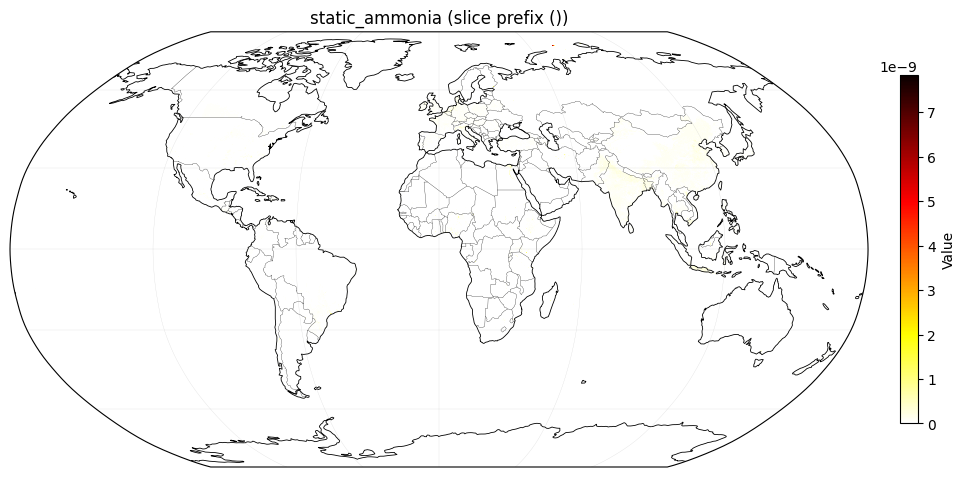

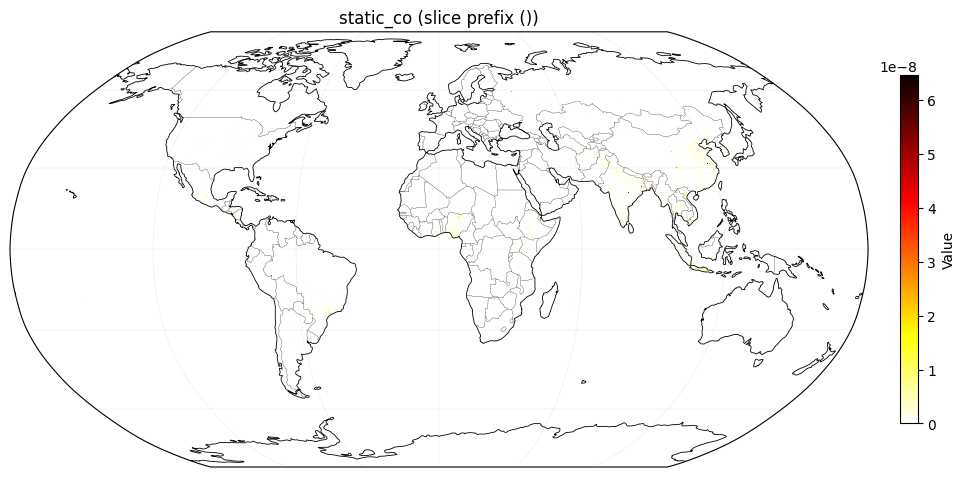

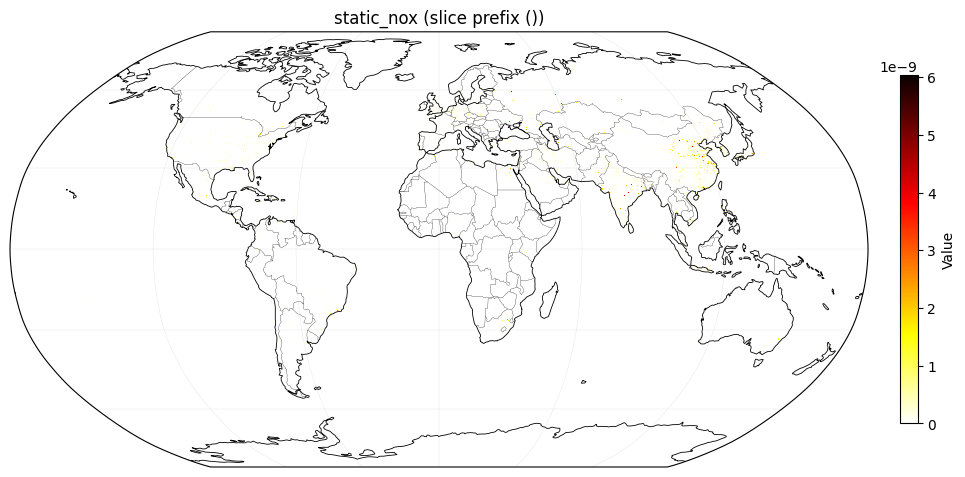

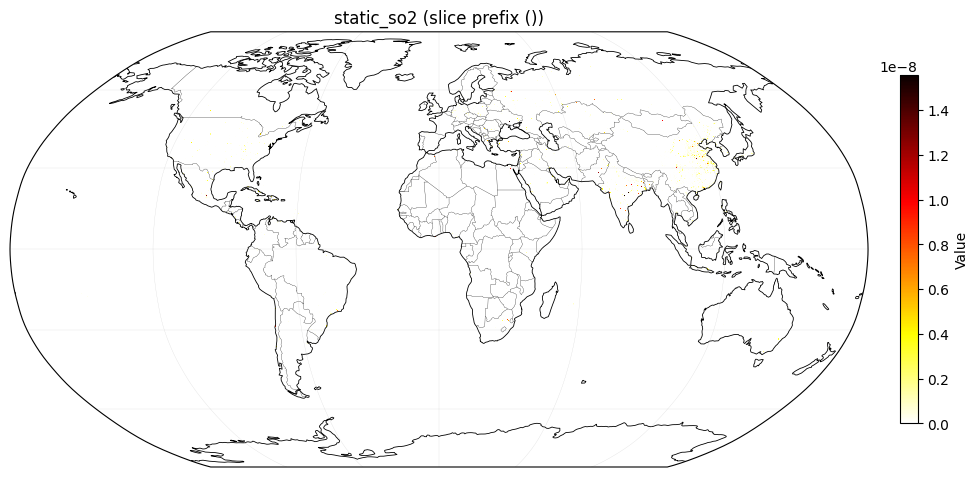

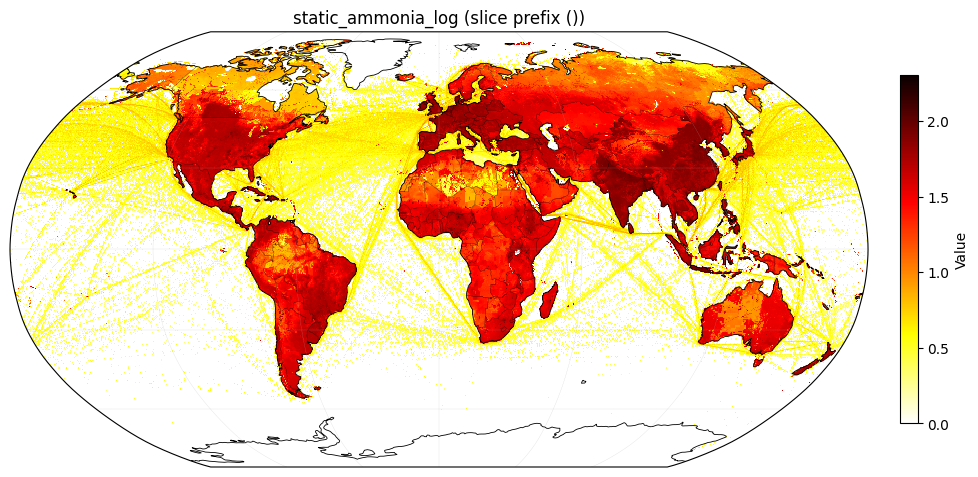

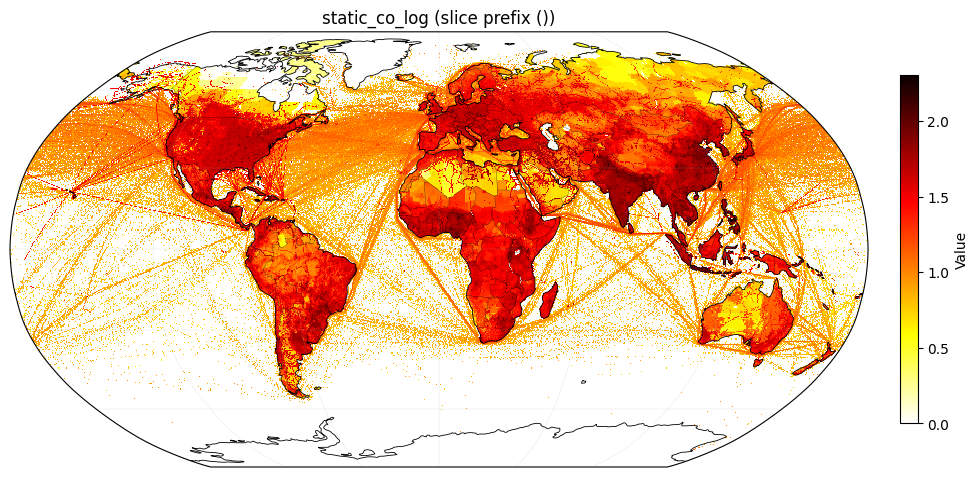

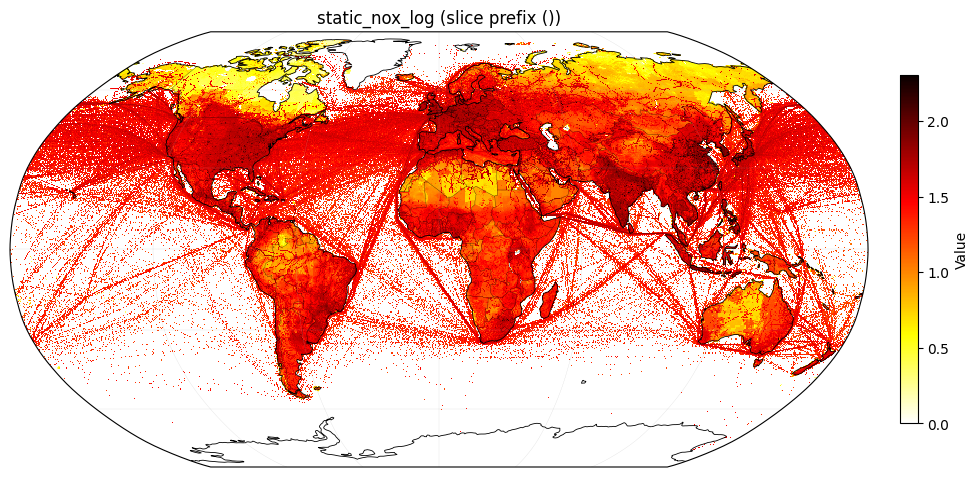

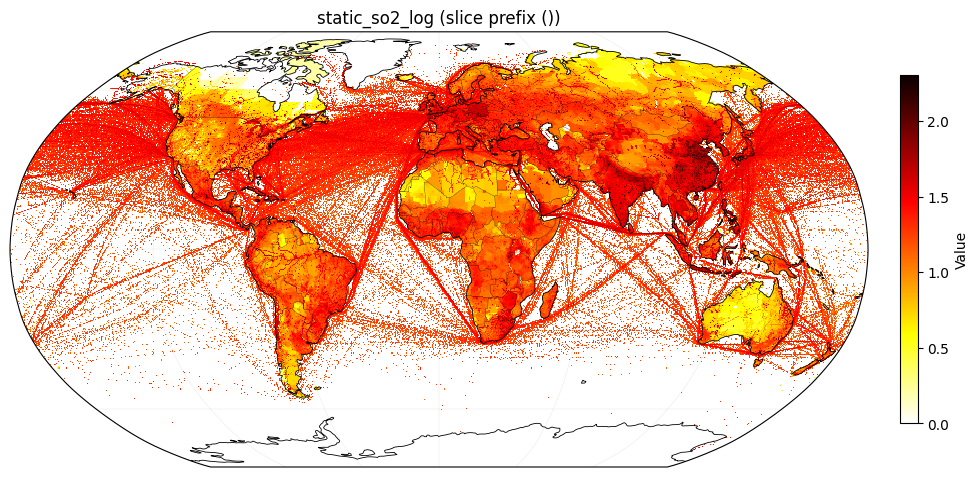

In [9]:
# Choose one or more variables to display.
PLOT_CANDIDATES = MODIFIABLE_BASE_VARS + [f"{name}_log" for name in MODIFIABLE_BASE_VARS]
EXTRA_PLOT_VARS = []  # Example: ["static_custom", "static_custom_log"]

for name in EXTRA_PLOT_VARS:
    if name in static_vars and name not in PLOT_CANDIDATES:
        PLOT_CANDIDATES.append(name)

VARS_TO_PLOT = [name for name in PLOT_CANDIDATES if name in static_vars]
STATIC_VMAX_SCALE = 0.1

if not VARS_TO_PLOT:
    raise ValueError("No target static emission variables found to plot.")

for var_name in VARS_TO_PLOT:
    arr = to_numpy_array(static_vars[var_name])
    arr2d, slice_info = to_2d_view(arr)
    lat, lon = infer_lat_lon(static_vars, arr2d)
    plot_vmax = None
    if var_name in MODIFIABLE_BASE_VARS:
        finite_mask = np.isfinite(arr2d)
        if finite_mask.any():
            plot_vmax = float(np.nanmax(arr2d[finite_mask]) * STATIC_VMAX_SCALE)
    plot_single_map(
        arr2d,
        lat,
        lon,
        title=f"{var_name} (slice prefix {slice_info})",
        cmap="hot_r",
        vmax=plot_vmax,
    )


In [7]:
# Modification settings (base variables only).
# Allowed base variables: static_ammonia, static_co, static_nox, static_so2.
# You may also use aliases: ammonia, co, nox, so2.
VAR_TO_MODIFY = MODIFIABLE_BASE_VARS[0]
VAR_TO_MODIFY = resolve_base_var_name(VAR_TO_MODIFY)
if VAR_TO_MODIFY not in MODIFIABLE_BASE_VARS:
    raise ValueError(
        f"VAR_TO_MODIFY must be one of {MODIFIABLE_BASE_VARS} "
        "(or alias: ammonia/co/nox/so2)."
    )

SCALE_FACTOR = 1.10
OFFSET = 0.0
LOG_EPS = 1e-12

# Optional regional editing (uses lat/lon bounds).
APPLY_REGION_MASK = False
LAT_BOUNDS = (-20.0, 20.0)
LON_BOUNDS = (100.0, 160.0)

# Optional save target for modified pickle.
SAVE_MODIFIED_PICKLE = False
OUTPUT_PICKLE_PATH = STATIC_PICKLE_PATH.with_name(STATIC_PICKLE_PATH.stem + "-modified.pickle")

print(f"Variable to modify: {VAR_TO_MODIFY}")
print(f"Transform: new = old * {SCALE_FACTOR} + {OFFSET}")
print(f"Log recompute epsilon: {LOG_EPS}")
if VAR_TO_MODIFY in BASE_TO_LOG_VAR:
    print(f"Paired log variable will be updated: {BASE_TO_LOG_VAR[VAR_TO_MODIFY]}")
if APPLY_REGION_MASK:
    print(f"Regional mask enabled: lat={LAT_BOUNDS}, lon={LON_BOUNDS}")


Variable to modify: static_ammonia
Transform: new = old * 1.1 + 0.0
Log recompute epsilon: 1e-12
Paired log variable will be updated: static_ammonia_log


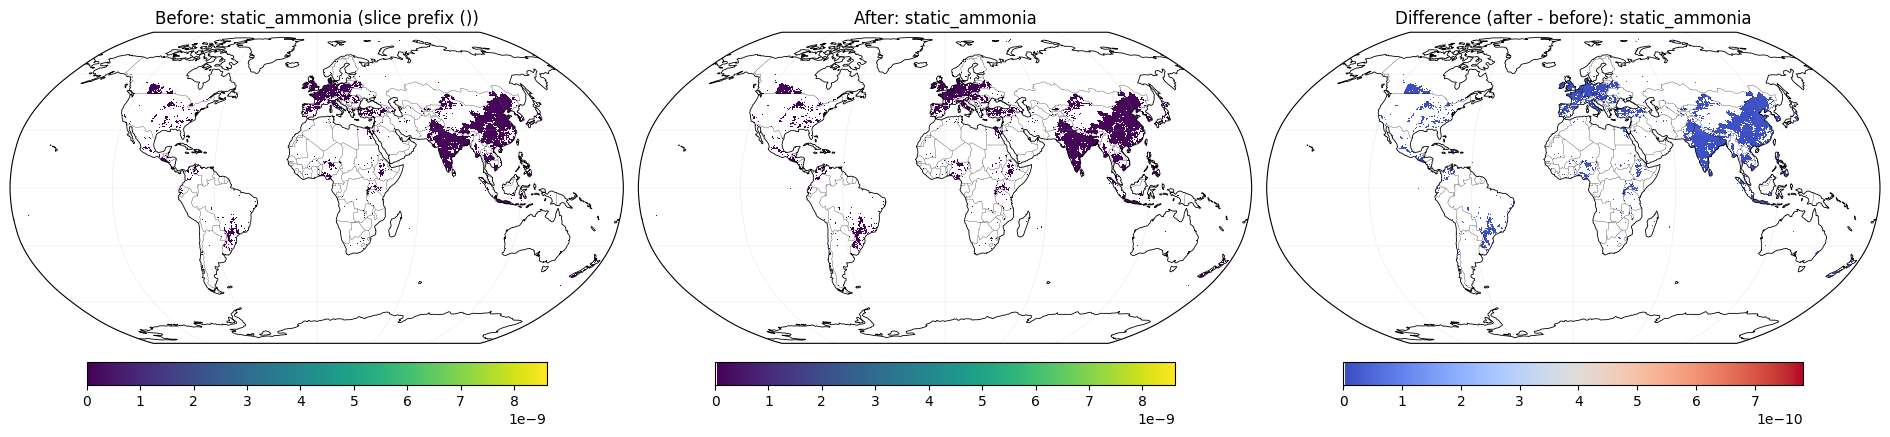

Updated paired log variable 'static_ammonia_log' from 'static_ammonia'.
Prepared modified static variables dict. Updated keys: ['static_ammonia', 'static_ammonia_log']


In [8]:
original_value = static_vars[VAR_TO_MODIFY]
original_np = np.array(to_numpy_array(original_value), copy=True)
modified_np = original_np.copy()

preview_2d, preview_slice = to_2d_view(original_np)
lat, lon = infer_lat_lon(static_vars, preview_2d)

if APPLY_REGION_MASK:
    lat_min, lat_max = sorted(LAT_BOUNDS)
    lon_min, lon_max = sorted(LON_BOUNDS)

    lon_wrapped = ((lon + 180.0) % 360.0) - 180.0
    lon_min_wrapped = ((lon_min + 180.0) % 360.0) - 180.0
    lon_max_wrapped = ((lon_max + 180.0) % 360.0) - 180.0

    lat_mask = (lat >= lat_min) & (lat <= lat_max)
    if lon_min_wrapped <= lon_max_wrapped:
        lon_mask = (lon_wrapped >= lon_min_wrapped) & (lon_wrapped <= lon_max_wrapped)
    else:
        lon_mask = (lon_wrapped >= lon_min_wrapped) | (lon_wrapped <= lon_max_wrapped)

    region_2d = np.outer(lat_mask, lon_mask)

    if modified_np.ndim == 2:
        modified_np[region_2d] = modified_np[region_2d] * SCALE_FACTOR + OFFSET
    else:
        flat = modified_np.reshape((-1, modified_np.shape[-2], modified_np.shape[-1]))
        for i in range(flat.shape[0]):
            flat[i][region_2d] = flat[i][region_2d] * SCALE_FACTOR + OFFSET
        modified_np = flat.reshape(modified_np.shape)
else:
    modified_np = modified_np * SCALE_FACTOR + OFFSET

before_2d, _ = to_2d_view(original_np)
after_2d, _ = to_2d_view(modified_np)
diff_2d = after_2d - before_2d

common_vmin = float(np.nanmin([before_2d.min(), after_2d.min()]))
common_vmax = float(np.nanmax([before_2d.max(), after_2d.max()]))
common_vmax = common_vmax * 0.1

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5),
    subplot_kw={"projection": ccrs.Robinson()},
)

m0 = _add_map(
    axes[0], before_2d, lat, lon,
    title=f"Before: {VAR_TO_MODIFY} (slice prefix {preview_slice})",
    cmap="viridis",
    vmin=common_vmin,
    vmax=common_vmax,
)
m1 = _add_map(
    axes[1], after_2d, lat, lon,
    title=f"After: {VAR_TO_MODIFY}",
    cmap="viridis",
    vmin=common_vmin,
    vmax=common_vmax,
)
m2 = _add_map(
    axes[2], diff_2d, lat, lon,
    title=f"Difference (after - before): {VAR_TO_MODIFY}",
    cmap="coolwarm",
)

plt.colorbar(m0, ax=axes[0], orientation="horizontal", shrink=0.75, pad=0.04)
plt.colorbar(m1, ax=axes[1], orientation="horizontal", shrink=0.75, pad=0.04)
plt.colorbar(m2, ax=axes[2], orientation="horizontal", shrink=0.75, pad=0.04)
plt.tight_layout()
plt.show()

modified_static_vars = dict(static_vars)
modified_static_vars[VAR_TO_MODIFY] = convert_back_to_template(original_value, modified_np)
updated_keys = [VAR_TO_MODIFY]

if VAR_TO_MODIFY in BASE_TO_LOG_VAR:
    log_var_name = BASE_TO_LOG_VAR[VAR_TO_MODIFY]
    log_np = compute_static_log(modified_np, eps=LOG_EPS)
    modified_static_vars[log_var_name] = convert_back_to_template(static_vars[log_var_name], log_np)
    updated_keys.append(log_var_name)
    print(f"Updated paired log variable '{log_var_name}' from '{VAR_TO_MODIFY}'.")
else:
    print(f"No paired log variable found for '{VAR_TO_MODIFY}'.")

print(f"Prepared modified static variables dict. Updated keys: {updated_keys}")
if SAVE_MODIFIED_PICKLE:
    with open(OUTPUT_PICKLE_PATH, "wb") as f:
        pickle.dump(modified_static_vars, f)
    print(f"Saved modified static variables to: {OUTPUT_PICKLE_PATH}")
